<img src="./Pics/MLSb-T.png" width="160">
<br><br>
<center><u><H1>Yolov2-training your own dataset</H1></u></center>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from darkflow.net.build import TFNet

ModuleNotFoundError: No module named 'darkflow'

In [ ]:
options = {"model": "cfg/yolov2-1c.cfg", 
           "load": "bin/yolov2.weights",
           "epoch": 100,
           "gpu": 0.8,
           "train": True,
           "annotation": "train/annotations",
           "dataset": "train/images"}

In [ ]:
tfnet = TFNet(options)

In [ ]:
%%time
tfnet.train()

In [ ]:
options = {"model": "cfg/yolov2-1c.cfg",
           "threshold":0.1,
           "load": -1,
           "gpu": 1.0}

In [ ]:
tfnet2 = TFNet(options)

In [ ]:
tfnet2.load_from_ckpt()

In [ ]:
original_img = cv2.imread("train/images/000004.jpg")
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
results = tfnet2.return_predict(original_img)
print(results)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(original_img)

In [ ]:
def plot_box(original_img , predictions):
    newImage = np.copy(original_img)

    for result in predictions:
        top_x = result['topleft']['x']
        top_y = result['topleft']['y']

        btm_x = result['bottomright']['x']
        btm_y = result['bottomright']['y']

        confidence = result['confidence'] * 100
        label = result['label'] + " " + str(round(confidence, 2))
        
        newImage = cv2.rectangle(newImage, (top_x, top_y), (btm_x, btm_y), (255,0,0), 5)
        newImage = cv2.putText(newImage, label, (top_x, top_y-5), cv2.FONT_ITALIC , 1, (0, 255, 0), 2)
        
    return newImage

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(plot_box(original_img, results))

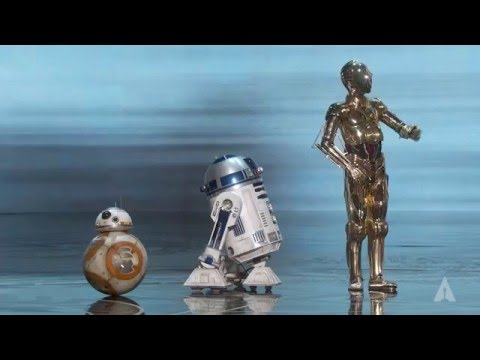

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('VkO62A_CycU')

In [2]:
#pip install pafy
#pip install --upgrade youtube_dl
import pafy

In [6]:
url = 'https://www.youtube.com/watch?v=VkO62A_CycU'
pa = pafy.new(url)
play = pa.getbest(preftype="webm")
cap = cv2.VideoCapture(play.url)

if (cap.isOpened() == False):
    print("Unable to read video")

width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)   
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT) 

fourcc = cv2.VideoWriter_fourcc(*'DIVX')
out = cv2.VideoWriter('R2D2.avi',fourcc, 20.0, (int(width), int(height)))

while(True):
    ret, frame = cap.read()
    
    if ret == True:
        frame = np.asarray(frame)      
        results = tfnet2.return_predict(frame)  
        new_frame = plot_box(frame, results)
        out.write(new_frame)
        cv2.imshow('frame', new_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        break

cap.release()
out.release()
cv2.destroyAllWindows()

NameError: name 'tfnet2' is not defined